In [1]:
# load all three databases, for prostate, bladder, and rectum
from sqlitedata import SqliteData
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

rectum_db_path = 'images/rectum/images_rectum.sqlite'
bladder_db_path = 'images/bladder/images_bladder.sqlite'
prostate_db_path = 'images/prostate/images_prostate.sqlite'

paths_dict = {'rectum': rectum_db_path,
              'bladder': bladder_db_path,
              'prostate': prostate_db_path}
dataframes = {'rectum': pd.DataFrame(),
              'bladder': pd.DataFrame(),
              'prostate': pd.DataFrame()}

for key, path in paths_dict.items():
    print(f'Loading {key} database from {path}')
    db = SqliteData(path)
    images, masks, pat_ids, cbct_ids = db.get_midline_images_and_masks(key)
    dataframes[key] = pd.DataFrame({
        'pat_id': pat_ids,
        'cbct_id': cbct_ids,
        'image': images,
        'mask': masks
    })
    dataframes[key]['pat_id'] = dataframes[key]['pat_id'].astype(str)
    dataframes[key]['cbct_id'] = dataframes[key]['cbct_id'].astype(str)
    print(f'Loaded {len(dataframes[key])} midline images for {key}')
    db.close()

Loading rectum database from images/rectum/images_rectum.sqlite
Loaded 666 midline images for rectum
Loading bladder database from images/bladder/images_bladder.sqlite
Loaded 666 midline images for rectum
Loading bladder database from images/bladder/images_bladder.sqlite
Loaded 707 midline images for bladder
Loading prostate database from images/prostate/images_prostate.sqlite
Loaded 138 midline images for prostate
Loaded 707 midline images for bladder
Loading prostate database from images/prostate/images_prostate.sqlite
Loaded 138 midline images for prostate


Found 131 CBCT scans with data in all three databases
Selected CBCT scans: ['1.2.752.243.1.1.20240418152501240.6396.31168', '1.2.752.243.1.1.20240426170504453.8800.52802', '1.2.752.243.1.1.20240423104708945.3107.63188']

Visualizing CBCT scan: 1.2.752.243.1.1.20240418152501240.6396.31168


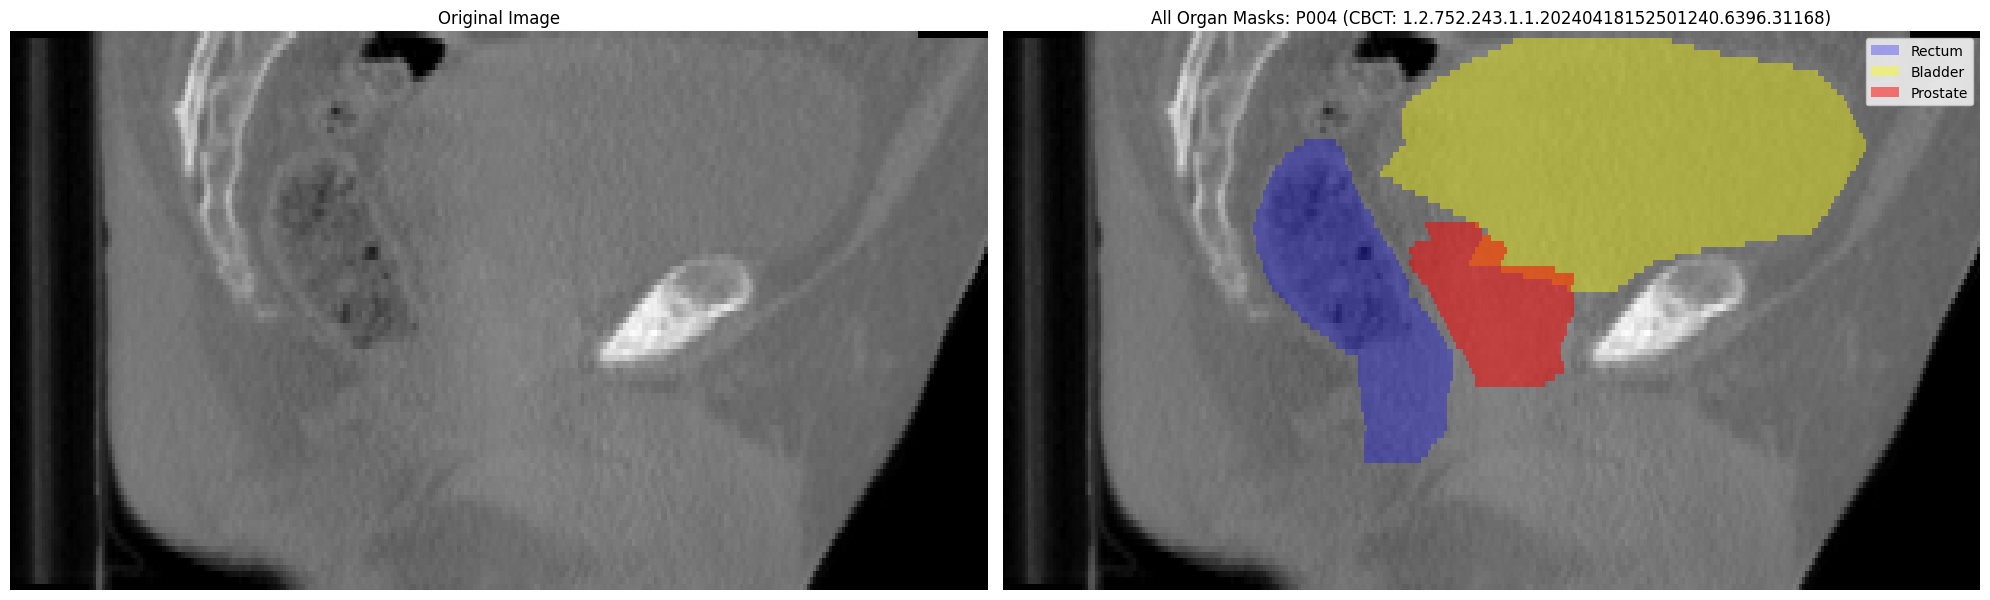


Visualizing CBCT scan: 1.2.752.243.1.1.20240426170504453.8800.52802


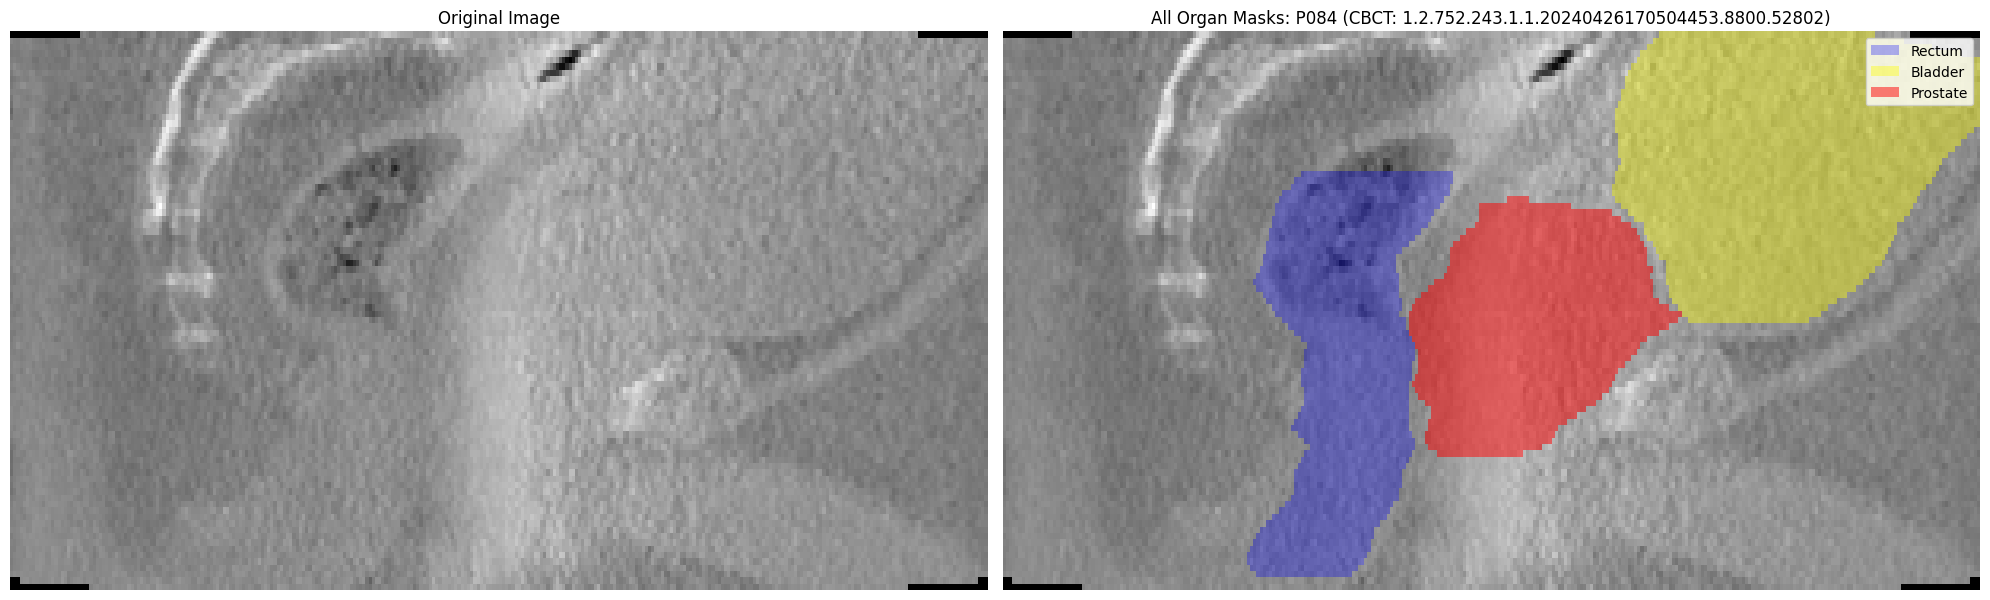


Visualizing CBCT scan: 1.2.752.243.1.1.20240423104708945.3107.63188


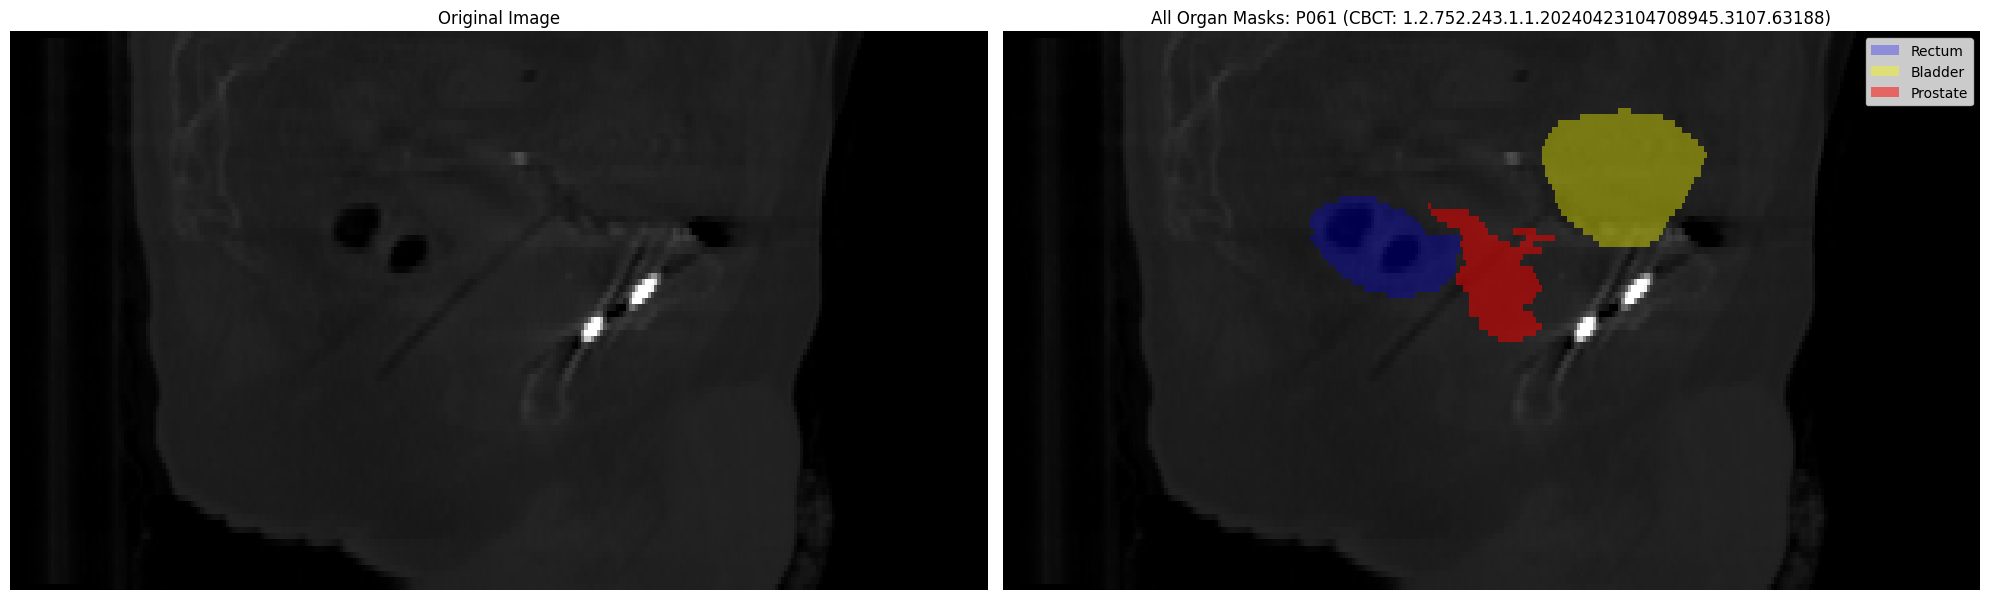


Visualization complete! Images saved as 'images/combined_masks_{cbct_id}.png'


In [2]:
# Find common CBCT scans across all three databases
common_cbcts = set(dataframes['rectum']['cbct_id']) & set(dataframes['bladder']['cbct_id']) & set(dataframes['prostate']['cbct_id'])
common_cbcts = list(common_cbcts)
print(f"Found {len(common_cbcts)} CBCT scans with data in all three databases")

# Select 3 random CBCT scans
import random
random.seed(42)  # For reproducibility
selected_cbcts = random.sample(common_cbcts, min(3, len(common_cbcts)))
print(f"Selected CBCT scans: {selected_cbcts}")

# Visualize each selected CBCT scan
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

for cbct_id in selected_cbcts:
    print(f"\nVisualizing CBCT scan: {cbct_id}")

    # Get data for this CBCT scan from each database
    rectum_data = dataframes['rectum'][dataframes['rectum']['cbct_id'] == cbct_id]
    bladder_data = dataframes['bladder'][dataframes['bladder']['cbct_id'] == cbct_id]
    prostate_data = dataframes['prostate'][dataframes['prostate']['cbct_id'] == cbct_id]

    if rectum_data.empty or bladder_data.empty or prostate_data.empty:
        print(f"Missing data for CBCT scan {cbct_id}, skipping...")
        continue

    # Get patient ID for display
    pat_id = rectum_data.iloc[0]['pat_id']

    # Get the first (and should be only) midline slice for each organ
    rectum_img = rectum_data.iloc[0]['image']
    rectum_mask = rectum_data.iloc[0]['mask']
    bladder_img = bladder_data.iloc[0]['image']
    bladder_mask = bladder_data.iloc[0]['mask']
    prostate_img = prostate_data.iloc[0]['image']
    prostate_mask = prostate_data.iloc[0]['mask']

    # Use rectum image as base (they should all be the same dimensions)
    base_img = rectum_img.copy()
    height, width = base_img.shape

    # Calculate cropping indices (remove 1/5 from each side, i.e., 20% of width)
    crop_width = int(width * 0.2)
    crop_slice = slice(crop_width, width - crop_width)

    # Crop all images and masks
    cropped_img = base_img[:, crop_slice]
    cropped_rectum_mask = rectum_mask[:, crop_slice]
    cropped_bladder_mask = bladder_mask[:, crop_slice]
    cropped_prostate_mask = prostate_mask[:, crop_slice]

    # Create figure with 1x2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Plot original cropped image
    sns.heatmap(cropped_img, ax=axes[0], cmap='gray', cbar=False)
    axes[0].set_title('Original Image')
    axes[0].set_aspect(2)
    axes[0].axis('off')

    # Plot overlaid masks
    sns.heatmap(cropped_img, ax=axes[1], cmap='gray', cbar=False)

    # Rectum mask (blue, translucent)
    rmask_zeros = cropped_rectum_mask == 0
    alpha = np.ones_like(cropped_rectum_mask, dtype=float) * 0.3
    alpha[rmask_zeros] = 0.0
    blue_cmap = ListedColormap(['none', 'blue'])
    sns.heatmap(cropped_rectum_mask, ax=axes[1], cmap=blue_cmap, alpha=alpha, cbar=False)

    # Bladder mask (yellow, translucent)
    bmask_zeros = cropped_bladder_mask == 0
    alpha = np.ones_like(cropped_bladder_mask, dtype=float) * 0.4
    alpha[bmask_zeros] = 0.0
    yellow_cmap = ListedColormap(['none', 'yellow'])
    sns.heatmap(cropped_bladder_mask, ax=axes[1], cmap=yellow_cmap, alpha=alpha, cbar=False)

    # Prostate mask (red, translucent)
    pmask_zeros = cropped_prostate_mask == 0
    alpha = np.ones_like(cropped_prostate_mask, dtype=float) * 0.5
    alpha[pmask_zeros] = 0.0
    red_cmap = ListedColormap(['none', 'red'])
    sns.heatmap(cropped_prostate_mask, ax=axes[1], cmap=red_cmap, alpha=alpha, cbar=False)

    # Add legend
    legend_elements = [
        Patch(facecolor='blue', alpha=0.3, label='Rectum'),
        Patch(facecolor='yellow', alpha=0.4, label='Bladder'),
        Patch(facecolor='red', alpha=0.5, label='Prostate')
    ]
    axes[1].legend(handles=legend_elements, loc='upper right')

    axes[1].set_aspect(2)
    axes[1].axis('off')
    axes[1].set_title(f'All Organ Masks: {pat_id} (CBCT: {cbct_id})')

    # Adjust layout
    plt.tight_layout()

    # Save the figure
    plt.savefig(f'images/combined_masks_{cbct_id}.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

print("\nVisualization complete! Images saved as 'images/combined_masks_{cbct_id}.png'")

In [3]:
validation_set_rectum = ['P005', 'P007', 'P029', 'P031', 'P033', 'P037', 'P043', 'P048', 'P051', 'P052', 'P060', 'P061', 'P063', 'P066', 'P068', 'P073', 'P074', 'P082', 'P100', 'P112', 'P114', 'P120', 'P122', 'P124', 'P129', 'P131']
validation_set_bladder = ['P012', 'P019', 'P027', 'P031', 'P038', 'P045', 'P047', 'P050', 'P051', 'P055', 'P056', 'P060', 'P062', 'P065', 'P067', 'P068', 'P090', 'P107', 'P109', 'P112', 'P116', 'P118', 'P119', 'P124', 'P127', 'P132']

Using device: cuda
Models loaded successfully
Common validation patients: ['P031', 'P051', 'P060', 'P068', 'P112', 'P124']
Found 34 validation CBCTs: ['1.2.752.243.1.1.20240709145112712.2116.58672', '1.2.752.243.1.1.20240709145112242.1752.13115', '1.2.752.243.1.1.20240709145112478.1934.48056', '1.2.752.243.1.1.20240423103418082.1151.18175', '1.2.752.243.1.1.20240708120319744.4826.34303', '1.2.752.243.1.1.20240709145112362.1843.68604', '1.2.752.243.1.1.20240708120319639.4735.17518', '1.2.752.243.1.1.20240424090245032.5330.64753', '1.2.752.243.1.1.20240424090244718.2600.60010', '1.2.752.243.1.1.20240424090244605.1690.24500', '1.2.752.243.1.1.20240422134430309.1534.63846', '1.2.752.243.1.1.20240423103417859.9690.81565', '1.2.752.243.1.1.20240709145112129.1661.47803', '1.2.752.243.1.1.20240423103417638.7870.12801', '1.2.752.243.1.1.20240708120319534.4644.15887', '1.2.752.243.1.1.20240423103417750.8780.50024', '1.2.752.243.1.1.20240423103417974.1060.54612', '1.2.752.243.1.1.2024042309594308

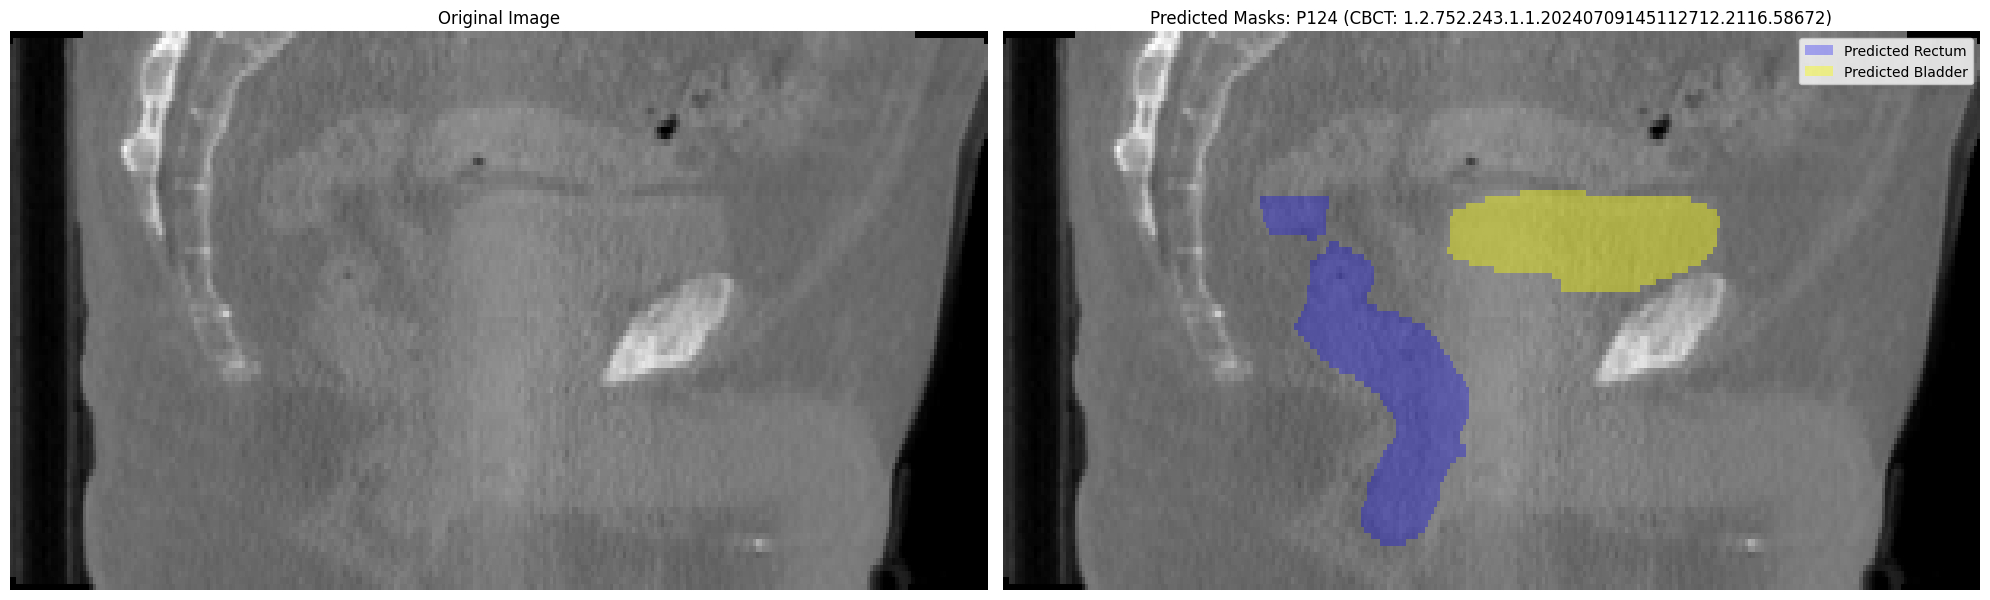


Processing validation CBCT scan: 1.2.752.243.1.1.20240709145112242.1752.13115


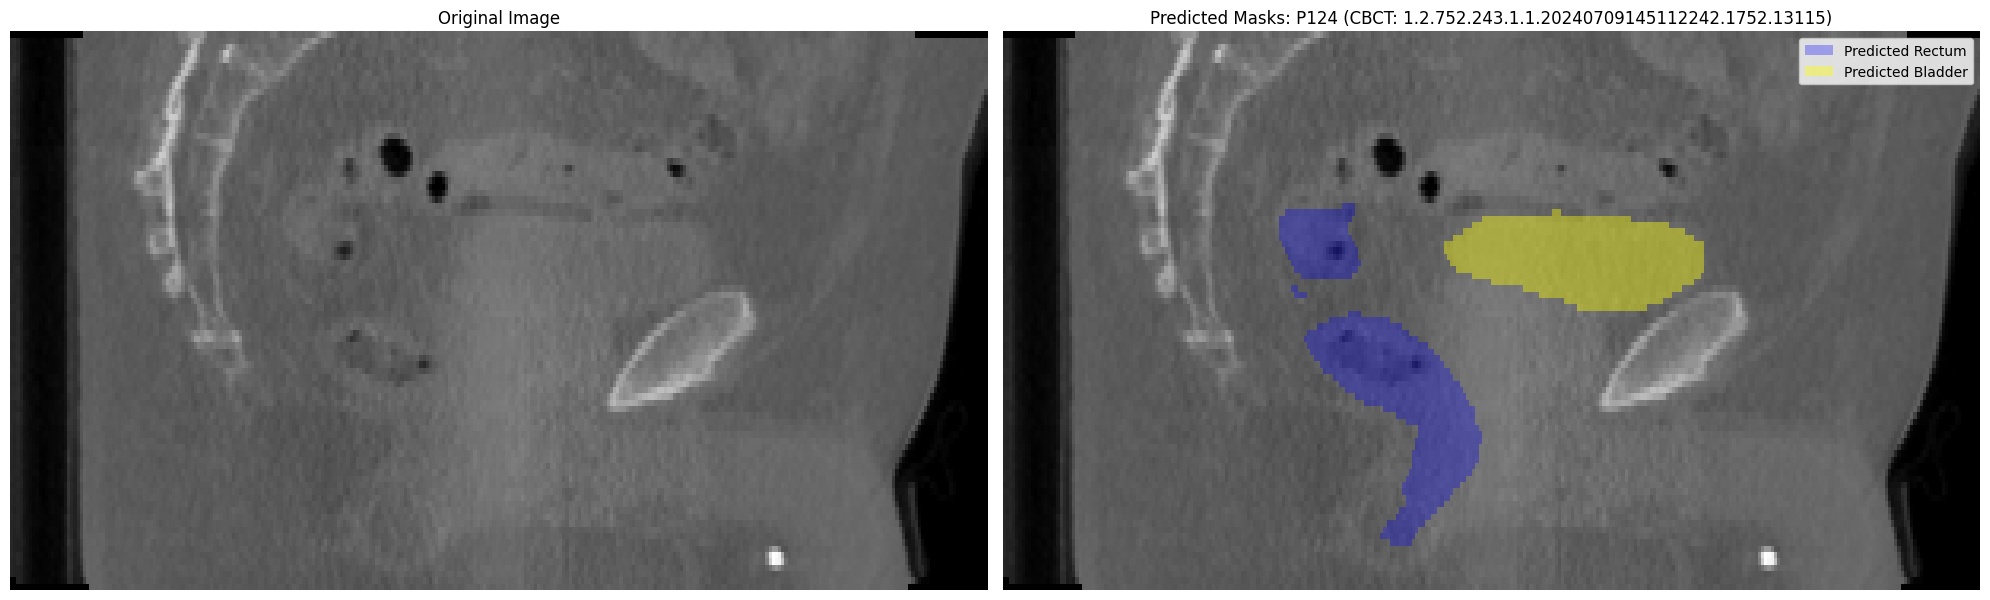


Processing validation CBCT scan: 1.2.752.243.1.1.20240709145112478.1934.48056


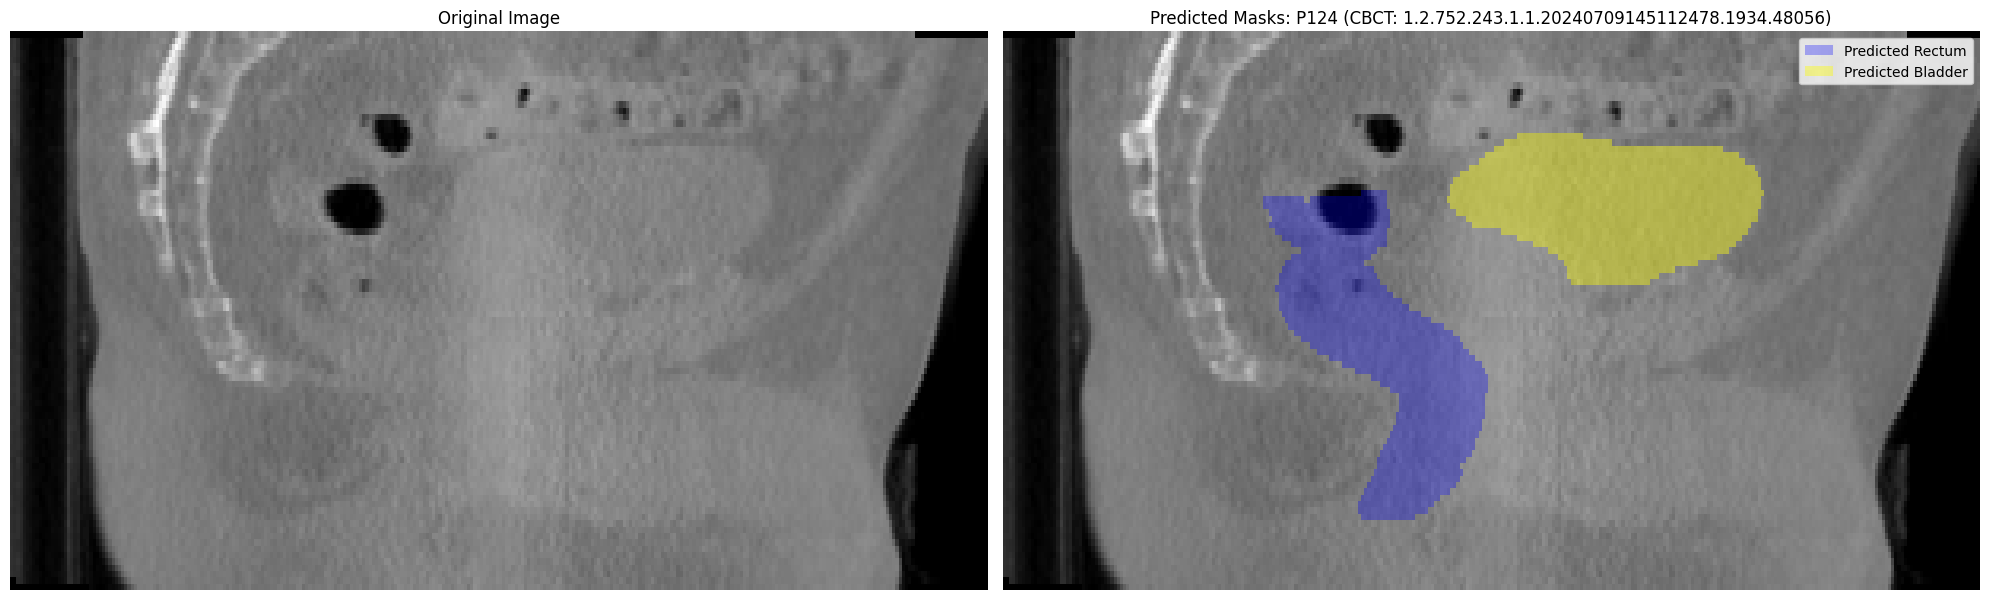


Validation prediction visualization complete! Images saved as 'images/predicted_masks_{cbct_id}.png'


In [5]:
# create images like above with bladder and rectum masks, as well as loading the
# models and applying them to the same slices, for the patients that are in both
# validation sets, e.g. pat 051 and 112

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)
        self.bottleneck = self.conv_block(512, 1024)
        self.upconv4 = self.upconv(1024, 512)
        self.decoder4 = self.conv_block(1024, 512)
        self.upconv3 = self.upconv(512, 256)
        self.decoder3 = self.conv_block(512, 256)
        self.upconv2 = self.upconv(256, 128)
        self.decoder2 = self.conv_block(256, 128)
        self.upconv1 = self.upconv(128, 64)
        self.decoder1 = self.conv_block(128, 64)
        self.conv_last = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def pad_and_concat(self, upsampled, bypass):
        diffY = bypass.size()[2] - upsampled.size()[2]
        diffX = bypass.size()[3] - upsampled.size()[3]
        upsampled = F.pad(upsampled, [diffX // 2, diffX - diffX // 2,
                                      diffY // 2, diffY - diffY // 2])
        return torch.cat([upsampled, bypass], dim=1)

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(F.max_pool2d(enc1, 2))
        enc3 = self.encoder3(F.max_pool2d(enc2, 2))
        enc4 = self.encoder4(F.max_pool2d(enc3, 2))
        bottleneck = self.bottleneck(F.max_pool2d(enc4, 2))
        dec4 = self.upconv4(bottleneck)
        dec4 = self.pad_and_concat(dec4, enc4)
        dec4 = self.decoder4(dec4)
        dec3 = self.upconv3(dec4)
        dec3 = self.pad_and_concat(dec3, enc3)
        dec3 = self.decoder3(dec3)
        dec2 = self.upconv2(dec3)
        dec2 = self.pad_and_concat(dec2, enc2)
        dec2 = self.decoder2(dec2)
        dec1 = self.upconv1(dec2)
        dec1 = self.pad_and_concat(dec1, enc1)
        dec1 = self.decoder1(dec1)
        return self.conv_last(dec1)

class ImageDataset(Dataset):
    def __init__(self, images):
        self.images = images
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = np.array(self.images.iloc[idx], dtype=np.float32)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(self.device)
        return img

# Load models
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

rectum_model = UNet(in_channels=1, out_channels=1).to(device)
rectum_model.load_state_dict(torch.load('models/model_rectum.pth', map_location=device))
rectum_model.eval()

bladder_model = UNet(in_channels=1, out_channels=1).to(device)
bladder_model.load_state_dict(torch.load('models/model_bladder.pth', map_location=device))
bladder_model.eval()

print("Models loaded successfully")

# Get common validation patients
common_validation_pats = set(validation_set_rectum) & set(validation_set_bladder)
print(f"Common validation patients: {sorted(common_validation_pats)}")

# Select CBCTs from common patients that have data in both rectum and bladder databases
validation_cbcts = []
all_rectum_cbcts = set(dataframes['rectum']['cbct_id'])
all_bladder_cbcts = set(dataframes['bladder']['cbct_id'])
common_rectum_bladder_cbcts = all_rectum_cbcts & all_bladder_cbcts

for cbct_id in common_rectum_bladder_cbcts:
    rectum_data = dataframes['rectum'][dataframes['rectum']['cbct_id'] == cbct_id]
    bladder_data = dataframes['bladder'][dataframes['bladder']['cbct_id'] == cbct_id]
    if not rectum_data.empty and not bladder_data.empty:
        pat_id = rectum_data.iloc[0]['pat_id']
        if pat_id in common_validation_pats:
            validation_cbcts.append(cbct_id)

print(f"Found {len(validation_cbcts)} validation CBCTs: {validation_cbcts}")

# Select a few for demonstration
selected_validation_cbcts = validation_cbcts[:3]  # or specify specific ones like ['some_id']
print(f"Selected validation CBCTs: {selected_validation_cbcts}")

def normalize_image(img):
    #only normalize if the image is not already in 0-1 range
    if img.max() <= 1.0:
        print("Image already normalized")
        return img
    return np.clip(img, 0, 8000) / 8000.0

def apply_model(model, img):
    img_norm = normalize_image(img)
    img_tensor = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.sigmoid(output).squeeze().cpu().numpy()
    return probs

# Visualize each selected validation CBCT scan with predicted masks
for cbct_id in selected_validation_cbcts:
    print(f"\nProcessing validation CBCT scan: {cbct_id}")

    # Get data for this CBCT scan
    rectum_data = dataframes['rectum'][dataframes['rectum']['cbct_id'] == cbct_id]
    bladder_data = dataframes['bladder'][dataframes['bladder']['cbct_id'] == cbct_id]

    pat_id = rectum_data.iloc[0]['pat_id']

    # Get the midline slice
    rectum_img = rectum_data.iloc[0]['image']
    bladder_img = bladder_data.iloc[0]['image']

    # Apply models to get predictions
    rectum_pred = apply_model(rectum_model, rectum_img)
    bladder_pred = apply_model(bladder_model, bladder_img)

    # Use rectum image as base (they should be the same)
    base_img = rectum_img.copy()
    height, width = base_img.shape

    # Calculate cropping indices
    crop_width = int(width * 0.2)
    crop_slice = slice(crop_width, width - crop_width)

    # Crop all images and predictions
    cropped_img = base_img[:, crop_slice]
    cropped_rectum_pred = rectum_pred[:, crop_slice]
    cropped_bladder_pred = bladder_pred[:, crop_slice]

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Plot original cropped image
    sns.heatmap(cropped_img, ax=axes[0], cmap='gray', cbar=False)
    axes[0].set_title('Original Image')
    axes[0].set_aspect(2)
    axes[0].axis('off')

    # Plot overlaid predicted masks
    sns.heatmap(cropped_img, ax=axes[1], cmap='gray', cbar=False)

    # Rectum prediction (blue, translucent)
    alpha = np.ones_like(cropped_rectum_pred, dtype=float) * 0.3
    alpha[cropped_rectum_pred < 0.5] = 0.0  # threshold at 0.5
    blue_cmap = ListedColormap(['none', 'blue'])
    sns.heatmap(cropped_rectum_pred > 0.5, ax=axes[1], cmap=blue_cmap, alpha=alpha, cbar=False)

    # Bladder prediction (yellow, translucent)
    alpha = np.ones_like(cropped_bladder_pred, dtype=float) * 0.4
    alpha[cropped_bladder_pred < 0.5] = 0.0
    yellow_cmap = ListedColormap(['none', 'yellow'])
    sns.heatmap(cropped_bladder_pred > 0.5, ax=axes[1], cmap=yellow_cmap, alpha=alpha, cbar=False)

    # Add legend
    legend_elements = [
        Patch(facecolor='blue', alpha=0.3, label='Predicted Rectum'),
        Patch(facecolor='yellow', alpha=0.4, label='Predicted Bladder')
    ]
    axes[1].legend(handles=legend_elements, loc='upper right')

    axes[1].set_aspect(2)
    axes[1].axis('off')
    axes[1].set_title(f'Predicted Masks: {pat_id} (CBCT: {cbct_id})')

    # Adjust layout
    plt.tight_layout()

    # Save the figure
    plt.savefig(f'images/predicted_masks_{pat_id}_{cbct_id}.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

print("\nValidation prediction visualization complete! Images saved as 'images/predicted_masks_{pat_id}_{cbct_id}.png'")